In [113]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from iminuit import Minuit, minimize
from iminuit.cost import UnbinnedNLL
from scipy import integrate

# Problem 1a

In [114]:
plt.style.use('seaborn-v0_8-colorblind')

colors = [plt.plot(1,1)[0].get_color() for _ in range(10)]
plt.close()

In [115]:
def PDF(x, mu, sigma, xi):
    return 1/sigma * (1 + xi * (x - mu) / sigma) ** (-1/xi - 1) * np.exp(-(1 + xi * (x - mu) / sigma) ** (-1/xi))

pred_normalized = lambda x, mu, sigma, xi: PDF(x, mu, sigma, xi) / integrate.quad(lambda x: PDF(x, mu, sigma, xi), 0.1, 3000)[0]

def log_likelihood_poly(data, mu, sigma, xi):   
    data_points = PDF(data, mu, sigma, xi)
    # if np.any(data_points <= 0):
    #     return np.inf
    return -np.sum(np.log(data_points))


def find_minimum(data, init_mu = 1000, init_sigma = 2000, init_xi = 0.1):    
    # MLL_minimize = lambda mu, sigma, xi: log_likelihood_poly(data, mu, sigma, xi)
    
    m = Minuit(UnbinnedNLL(data, PDF), mu=init_mu, sigma=init_sigma, xi=init_xi)
    m.limits = [(None, None), (0.1, None), (None, None)]
    m.migrad()
    return m

# csv manip
Removed one comma line 151, since there was a club
changen O0 to 00

In [116]:
data = pd.read_csv('Liverpool10k2026.csv', delimiter=',')
#time to seconds
data['Time'] = pd.to_timedelta(data['Time']).dt.total_seconds()

data

,First Name,Last Name,Gender,Club,Time
0,Joshua,Garcia,Male,NaN,2544.0
1,William,Young,Male,NaN,3078.0
2,Renee,Daniel,Female,NaN,2489.0
3,Timothy,Barnes,Male,NaN,3145.0
4,Juan,Hensley,Male,North Endurance,2571.0
...,...,...,...,...,...
193,Larry,Owens,Male,NaN,2466.0
194,Pamela,Oliver,Female,NaN,4205.0
195,Jacob,Martin,Male,Dockside Runners,2798.0
196,Kerry,Smith,Female,NaN,3861.0


In [117]:
m = find_minimum(data['Time'], init_mu = 3000, init_sigma = 600, init_xi = -0.1)
m

C:\Users\lorentsen\AppData\Local\Temp\ipykernel_278576\673015219.py:2: RuntimeWarning: invalid value encountered in power
  return 1/sigma * (1 + xi * (x - mu) / sigma) ** (-1/xi - 1) * np.exp(-(1 + xi * (x - mu) / sigma) ** (-1/xi))


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3120                       │              Nfcn = 88               │
│ EDM = 4.61e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ mu    │  2.96e3   │  0.05e3   │            │            │         │         │       │
│ 1 │ sigma │    610    │    40     │            │            │   0.1   │         │       │
│ 2 │ xi    │   -0.22   │   0.06    │            │            │         │         │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬────────────────────────────┐
│       │       mu    sigma       xi │
├───────┼────────────────────────────┤
│    mu │ 2.47e+03    0.3e3   -1.297 │
│ sigma │    0.3e3 1.33e+03   -1.280 │
│    xi │   -1.297   -1.280  0.00357 │
└───────┴────────────────────────────┘

Estimated parameters: mu = 2960.8287540712895, sigma = 613.7229949911017, xi = -0.2219280191176603
-LLH at parameters is -3120.081187798935


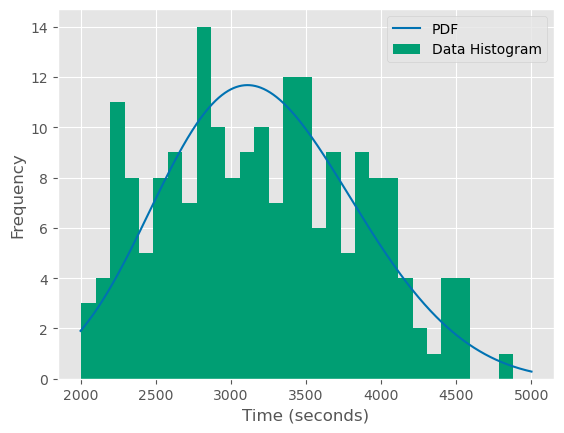

In [ ]:
test_data = np.linspace(2000, 5000, 1000)

mu, sigma, xi = tuple(m.values)
print(f"Estimated parameters: mu = {mu}, sigma = {sigma}, xi = {xi}")
print(f"-LLH at parameters is {-m.fval}") #????????????
pdf = PDF(test_data, mu, sigma, xi)

plt.style.use('ggplot')

#plt.hist: density = counts / (sum(counts) * np.diff(bins))
hist = np.histogram(data['Time'], bins=30)
counts_sum = hist[0].sum()
bin_width = np.diff(hist[1])[0]

plt.style.use('seaborn-v0_8-colorblind')

plt.plot(test_data, pdf*bin_width*counts_sum, label='PDF', color = colors[0])
plt.hist(data['Time'], bins = 30, label='Data Histogram', color = colors[1]);
plt.legend()
plt.xlabel('Time (seconds)')
plt.ylabel('Frequency');
# plt.title('Histogram of Time with Fitted (and scaled) PDF')
plt.savefig("699c8ae84110ffd670e39a3a\\Figures\\PDFhist.svg")


# Problem 1b

In [119]:
display(data[data["First Name"] == "Tanyusha"])
tanyusha_time = float(data[data["First Name"] == "Tanyusha"]["Time"].iloc[0])
theo_prob = integrate.quad(lambda x: PDF(x, *m.values), 0, tanyusha_time)[0]
actual_prob = data[data["Time"] < tanyusha_time].shape[0]/data.shape[0]

print(f"Theoretical probability of runners finishing before Tanyusha: {theo_prob:.4f}")
print(f"Actual fraction of runners finishing before Tanyusha: {actual_prob:.4f}")

,First Name,Last Name,Gender,Club,Time
133,Tanyusha,SomethingAboutGoats,Female,NaN,3747.0


Theoretical probability of runners finishing before Tanyusha: 0.8013
Actual fraction of runners finishing before Tanyusha: 0.7677


# Problem 1c

Probability of getting a time faster than fastest time is 0.0218


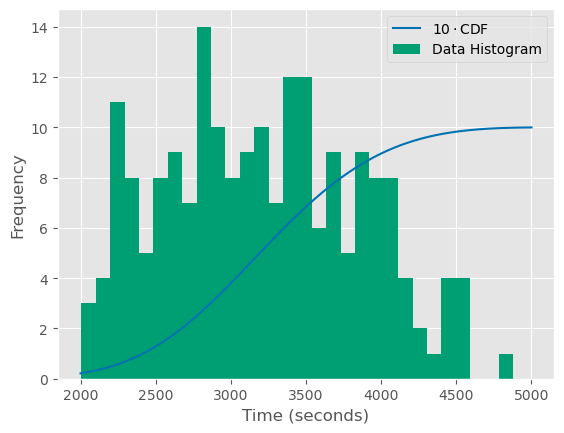

In [ ]:
test_data = np.linspace(2000, 5000, 1000)

def CDF(x, mu, sigma, xi):
    return np.exp(-(1 + xi * (x - mu) / sigma) ** (-1/xi))

mu, sigma, xi = (2980,607.5, -0.26)
cdf = CDF(test_data, mu, sigma, xi)


#plt.hist: density = counts / (sum(counts) * np.diff(bins))
hist = np.histogram(data['Time'], bins=30)
counts_sum = hist[0].sum()
bin_width = np.diff(hist[1])[0]

plt.style.use('ggplot')

plt.plot(test_data, 10*cdf, label='$10\\cdot$CDF', color = colors[0])
plt.hist(data['Time'], bins = 30, label='Data Histogram', color = colors[1]);
plt.legend()
plt.xlabel('Time (seconds)')
plt.ylabel('Frequency');
# plt.title('Histogram of Time with Fitted (and scaled) PDF')
print(f"Probability of getting a time faster than fastest time is {CDF(data['Time'].min(), mu, sigma, xi):.4f}")
plt.savefig("699c8ae84110ffd670e39a3a\\Figures\\CDFhist.svg")


# Problem 2

In [121]:
import math

In [122]:
def likelihood_unnormalized(x, alpha=2, beta=2):
    return beta**alpha*x**(alpha-1)*np.exp(-beta*x)/math.gamma(alpha)
likelihood = lambda x, alpha=2, beta=2: likelihood_unnormalized(x, alpha, beta) / integrate.quad(lambda x: likelihood_unnormalized(x, alpha, beta), 0, np.inf)[0]

# prior_single = lambda x: 1 if 0 < x < 1.6 else (2.66 if 1.6 <= x < 2.1 else 0)
def prior_unnormalized(x):
    return np.piecewise(x, [(0 < x)* (x <= 1.6), (1.6 < x)*(x <= 2.1), x <= 0, x>2.1], [1, 2.66, 0, 0])
prior = lambda x: prior_unnormalized(x) / integrate.quad(prior_unnormalized, 0, 2.1)[0]

posterior_unnormalized = lambda x, alpha=2, beta=2: likelihood(x, alpha, beta) * prior(x)
posterior = lambda x, alpha=2, beta=2: posterior_unnormalized(x, alpha, beta) / integrate.quad(lambda x: posterior_unnormalized(x, alpha, beta), 0, 4)[0]

Most likely value of x: 0.5005


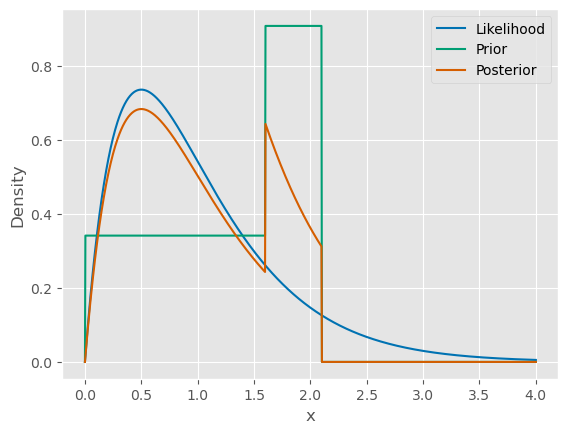

In [ ]:
xs = np.linspace(0, 4, 1000)
# prior_unnormalized(xs)
llh = likelihood(xs)
pri = prior(xs)
pos = posterior(xs)

plt.style.use('ggplot')

plt.plot(xs, llh, label='Likelihood', color = colors[0])
plt.plot(xs, pri, label='Prior', color = colors[1])
plt.plot(xs, pos, label='Posterior', color = colors[2])
plt.legend()
plt.xlabel('x')
plt.ylabel('Density');
print(f"Most likely value of x: {xs[np.argmax(pos)]:.4f}")
plt.savefig("699c8ae84110ffd670e39a3a\\Figures\\LLHpriorPost.svg")


# Problem 3

In [ ]:
def crab_walk(start_pos = [3.6, -2.0], ISLAND_RADIUS_SQUARED = 25, NR_OF_DAYS = 200, STEP_LENGTH = 0.2):
    move_dir = np.random.uniform(0, 2*np.pi, size=NR_OF_DAYS)
    positions = np.ones((NR_OF_DAYS+1, 2))
    positions[0] = start_pos
    for j in range(1, NR_OF_DAYS+1):
        positions[j] = positions[j-1] + STEP_LENGTH*np.array([np.cos(move_dir[j-1]), np.sin(move_dir[j-1])])
        if positions[j][0]**2 + positions[j][1]**2 >= ISLAND_RADIUS_SQUARED:
            # dist_off_island = positions[j][0]*np.cos(move_dir[j-1]) - positions[j][1]*np.sin(move_dir[j-1]) + np.sqrt((positions[j][0]*np.cos(move_dir[j-1]) + positions[j][1]*np.sin(move_dir[j-1]))**2+ ISLAND_RADIUS_SQUARED - (positions[j][0]**2 + positions[j][1]**2))
            # print(dist_off_island)
            a = (positions[j][1]-positions[j-1][1]) / (positions[j][0] - positions[j-1][0])
            b = positions[j][1] - a*positions[j][0] #Get line from current to previous position
            D_x = np.sqrt(4*a**2*b**2 - 4*(1+a**2)*(b**2-ISLAND_RADIUS_SQUARED)) #Calculate intersect of line with circle
            x_intersect_plus = ( -2*a*b + D_x)/(2+2*a**2)
            x_intersect_minus = ( -2*a*b - D_x)/(2+2*a**2)
            D_y = np.sqrt(4*b**2/a**4 - 4*(1/a**2 + 1)*(b**2/a**2 - ISLAND_RADIUS_SQUARED))
            y_intersect_plus = ( 2*b/a**2 + D_y)/(2/a**2+2)
            y_intersect_minus = ( 2*b/a**2 - D_y)/(2/a**2+2)
            dist_off_island = np.min([ #Find whih combination of solutions to the quadratic formulas are closest to the current position
                np.sqrt((positions[j][0]-x_intersect_plus)**2 + (positions[j][1]-y_intersect_plus)**2), 
                np.sqrt((positions[j][0]-x_intersect_minus)**2 + (positions[j][1]-y_intersect_minus)**2),
                np.sqrt((positions[j][0]-x_intersect_plus)**2 + (positions[j][1]-y_intersect_minus)**2), 
                np.sqrt((positions[j][0]-x_intersect_minus)**2 + (positions[j][1]-y_intersect_plus)**2)
            ])
            #Move back in the opposite direction by the distance off the island plus a small epsilon to ensure we are back on the island
            positions[j] = positions[j] + (dist_off_island + 0.0001)*np.array([np.cos(move_dir[j-1]-np.pi), np.sin(move_dir[j-1]-np.pi)])
        if positions[j][0]**2 + positions[j][1]**2 >= ISLAND_RADIUS_SQUARED:
            print("Error: crab is still off the island after correction.")
            # print(np.sqrt(positions[j][0]**2 + positions[j][1]**2) - np.sqrt(ISLAND_RADIUS_SQUARED))
    return positions
positions = crab_walk()
# print(positions)
fig, axs = plt.subplots(figsize=(6,6))
axs.plot(positions[:,0], positions[:,1])
circle = plt.Circle((0, 0), 5, fill=False)
axs.add_patch(circle)
# axs.set_aspect('equal', adjus# table='datalim')
axs.set_xlabel('x [km]')
axs.set_ylabel('y [km]');

# Problem 3b

In [125]:
def crab_walk_until_beach(start_pos = [3.6, -2.0], ISLAND_RADIUS_SQUARED = 25, NR_OF_DAYS = 200, STEP_LENGTH = 0.2):
    # move_dir = np.random.uniform(0, 2*np.pi, size=NR_OF_DAYS)
    positions = []
    positions.append(start_pos)
    while True:
        move_dir = np.random.uniform(0, 2*np.pi)
        positions.append(positions[-1] + STEP_LENGTH*np.array([np.cos(move_dir), np.sin(move_dir)]))
        if positions[-1][0]**2 + positions[-1][1]**2 >= ISLAND_RADIUS_SQUARED:
            break
    return positions

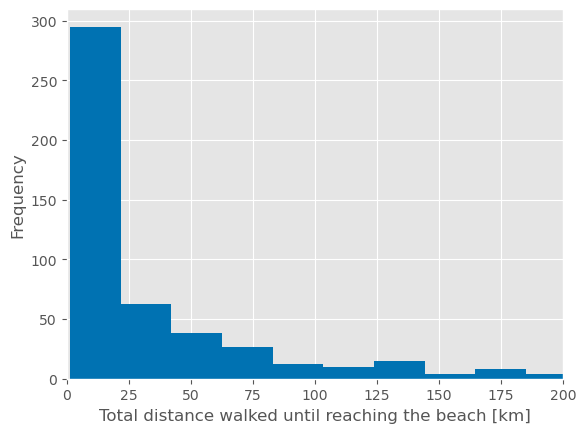

In [ ]:
NR_OF_SIMS = 501
distances = np.zeros(NR_OF_SIMS)
for i in range(NR_OF_SIMS):
    positions = crab_walk_until_beach(NR_OF_DAYS=1_000_000_000)
        # distances[i] = np.sum(np.diff(positions[:, 0])**2 + np.diff(positions[:, 1])**2)
    # plt.hist(distances, bins=30);
    sim_dists = np.sqrt(np.diff(np.asarray(positions)[:, 0])**2 + np.diff(np.asarray(positions)[:, 1])**2)
    # idx = np.argmax(distances < 2e-01 - 0.0001)
    # if idx == 0:
    #     idx = 200
    distances[i] = np.sum(sim_dists)
    
plt.style.use('ggplot')

plt.hist(distances, bins=30, color = colors[0])
plt.xlim(0, 200)
plt.xlabel('Total distance walked until reaching the beach [km]')
plt.ylabel('Frequency');
plt.savefig("699c8ae84110ffd670e39a3a\\Figures\\DistUntilBeach.svg")



# Problem 3c & 3d

In [127]:
from scipy.spatial import distance

In [128]:
class Crab:
    def __init__(self, pos, mass):
        self.pos = pos
        self.mass = mass

In [129]:
# def loserwinner(winner, loser):
def fight(crab1, crab2): 
    tot_m = crab1.mass + crab2.mass
    p1_win_prob = crab1.mass / tot_m
    if np.random.rand() < p1_win_prob:
        crab1.mass += crab2.mass
        crab2.mass = max([crab2.mass - crab1.mass, 0])
    else:
        crab2.mass += crab1.mass
        crab1.mass = max([crab1.mass - crab2.mass, 0])


In [130]:

def crab_fights(crab_arr, NR_OF_DAYS_TOT=200):
    for i in range(NR_OF_DAYS_TOT):
        # print(sum([crab.mass for crab in crab_arr]))
        for crab in crab_arr:
            if crab.mass <= 0:
                crab.pos = [np.inf, np.inf]
                continue
            crab.pos = crab_walk(start_pos=crab.pos, NR_OF_DAYS=1)[-1]

        crab_positions = [crab.pos for crab in crab_arr]
        distance_matrix = distance.cdist(crab_positions, crab_positions, "euclidean")
        # pairwise_distances(np.array(crab_positions))
        distance_matrix[distance_matrix == 0] = np.inf
        where = np.where(distance_matrix < 0.175)
        fights = np.array(where)[:, np.argsort(distance_matrix[where])][:, ::2] #In order of closest to furthest, take every second one to avoid duplicates
        if fights.shape[1] == 0:
            continue
        for j in range(fights.shape[1]):
            # print(i)
            # print(fights)
            crab1 = crab_arr[fights[0, j]]
            crab2 = crab_arr[fights[1, j]]
            if crab1.mass <= 0 or crab2.mass <= 0:
                continue
            fight(crab1, crab2)
    return crab_arr


In [132]:
start_positions = np.genfromtxt("CrabStartPositions.txt", delimiter=' ')

NR_OF_RUNS = 1000
max_crab = np.zeros(NR_OF_RUNS)
num_crabs = np.zeros(NR_OF_RUNS)
days_until_10_crabs_dead = np.zeros(NR_OF_RUNS)

for i in range(NR_OF_RUNS):
    crab_arr = [Crab(pos, 1) for pos in start_positions]
    crab_final_arr = crab_fights(crab_arr)
    max_crab[i] = max(crab.mass for crab in crab_final_arr)
    num_crabs[i] = len([crab.mass for crab in crab_final_arr if crab.mass > 0])
# max_crab

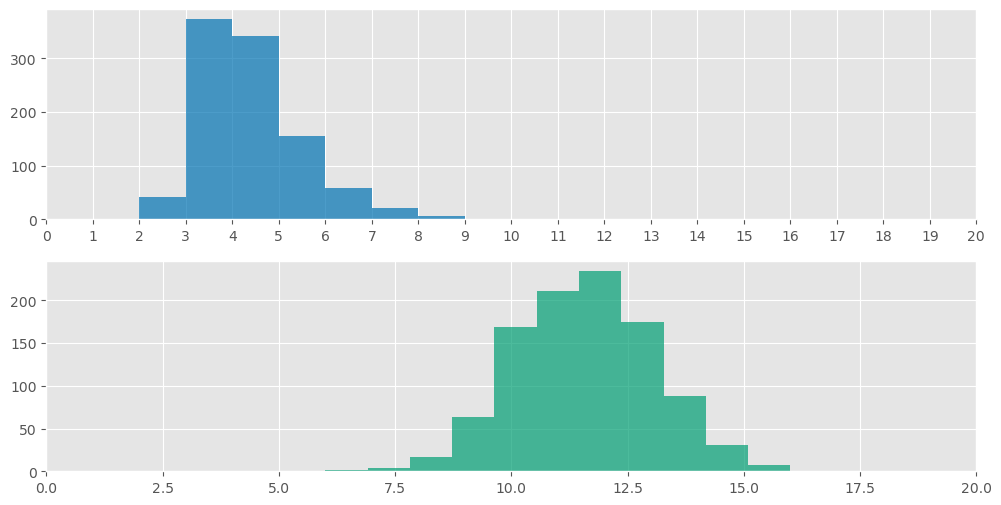

In [ ]:
plt.style.use('ggplot')

fig, axs = plt.subplots(2, 1, figsize = (12, 6))
axs[0].hist(max_crab, bins=len(list(set(max_crab))), alpha = 0.7, label = "Maximum mass of crabs", color = colors[0])
axs[0].set_xlim(0, 20)
axs[0].set_xticks(range(21))


# plt.show()
axs[1].hist(num_crabs, bins=len(list(set(num_crabs))), alpha = 0.7, label = "Number of surviving crabs", color = colors[1])
axs[1].set_xlim(0, 20)
# axs.set_xticks(range(21))
plt.savefig("699c8ae84110ffd670e39a3a\\Figures\\HistMaxAndMass.svg")

plt.show()


In [134]:
def crab_fights_until_cond(crab_arr, NR_OF_DAYS_TOT=2_000_000_000):
    # nr_of_dead_crabs = np.zeros(NR_OF_DAYS_TOT)
    for i in range(NR_OF_DAYS_TOT):
        # print(sum([crab.mass for crab in crab_arr]))
        for crab in crab_arr:
            if crab.mass <= 0:
                crab.pos = [np.inf, np.inf]
                continue
            crab.pos = crab_walk(start_pos=crab.pos, NR_OF_DAYS=1)[-1]

        crab_positions = [crab.pos for crab in crab_arr]
        distance_matrix = distance.cdist(crab_positions, crab_positions, "euclidean")
        distance_matrix[distance_matrix == 0] = np.inf
        where = np.where(distance_matrix < 0.175)
        fights = np.array(where)[:, np.argsort(distance_matrix[where])][:, ::2] #In order of closest to furthest, take every second one to avoid duplicates
        if fights.shape[1] == 0:
            continue
        for j in range(fights.shape[1]):
            # print(i)
            # print(fights)
            crab1 = crab_arr[fights[0, j]]
            crab2 = crab_arr[fights[1, j]]
            if crab1.mass <= 0 or crab2.mass <= 0:
                continue
            fight(crab1, crab2)
        sum([crab.mass <= 0 for crab in crab_arr])
        if sum([crab.mass <= 0 for crab in crab_arr]) >= 10:
            return i
    print(f"crabs not dead after {NR_OF_DAYS_TOT} days")

In [135]:
NR_OF_RUNS = 1000
days_until_10_crabs_dead = np.zeros(NR_OF_RUNS)

for i in range(NR_OF_RUNS):
    crab_arr = [Crab(pos, 1) for pos in start_positions]
    days_until_10_crabs_dead[i] = crab_fights_until_cond(crab_arr)


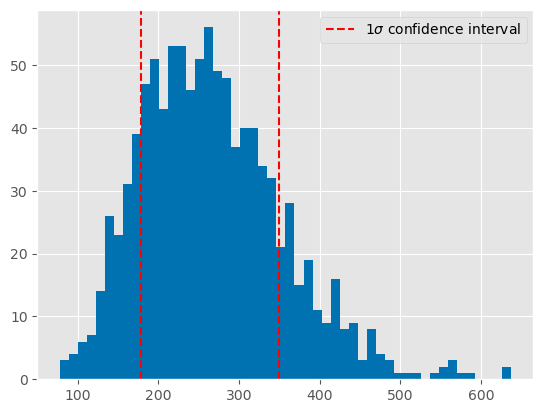

FileNotFoundError: [Errno 2] No such file or directory: '699c8ae84110ffd670e39a3a\\Figures\\DaysUntil10.svg'

<Figure size 640x480 with 0 Axes>

In [136]:
plt.style.use('ggplot')

plt.hist(days_until_10_crabs_dead[days_until_10_crabs_dead < np.inf], bins=50, color = colors[0])
sorted_days_until_10_crabs_dead = np.sort(days_until_10_crabs_dead[days_until_10_crabs_dead < np.inf])
CONFIDENCE_LEVEL = (1 - 0.6827)/2
lower_conf, upper_conf = (
    sorted_days_until_10_crabs_dead[int(np.floor(CONFIDENCE_LEVEL * sorted_days_until_10_crabs_dead.shape[0]))], 
    sorted_days_until_10_crabs_dead[int(np.floor((1 - CONFIDENCE_LEVEL) * sorted_days_until_10_crabs_dead.shape[0]))]
    )
plt.axvline(lower_conf, color='red', linestyle='dashed', label=f'$1\\sigma$ confidence interval')
plt.axvline(upper_conf, color='red', linestyle='dashed')
plt.legend()
plt.show()
plt.savefig("699c8ae84110ffd670e39a3a\\Figures\\DaysUntil10.svg")
# print(f"Amount of runs not getting to 10 dead crabs: {sum(days_until_10_crabs_dead == np.inf)} out of {NR_OF_RUNS}")
print(f"Confidence interval for days until 10 crabs are dead: [{int(lower_conf)}, {int(upper_conf)}]")

In [ ]:
plt.style.use('ggplot')
